The following Code takes the variable domain amino acid sequences from anarci_results.csv and via clustal omega takes out a msa to create consensus sequences for every gene family. 

In [65]:
import pandas as pd
from Bio import SeqIO, AlignIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.Align import MultipleSeqAlignment
from Bio.Align.Applications import ClustalOmegaCommandline
from collections import Counter
import os

def extract_genfamily(seq_name):
    parts = seq_name.split('|')
    if len(parts) >= 4:
        return parts[3]  # heavy_subclass, z.B. IGHV1
    return None

def consensus_from_alignment(alignment):
    consensus = []
    aln_length = alignment.get_alignment_length()
    for i in range(aln_length):
        column = alignment[:, i]
        most_common = Counter(column).most_common(1)[0][0]
        consensus.append(most_common)
    return "".join(consensus)

def run_clustalo(sequences, output_prefix):
    input_fasta = output_prefix + ".input.fasta"
    msa_fasta = output_prefix + ".msa.fasta"
    
    SeqIO.write(sequences, input_fasta, "fasta")
    
    clustalomega_cline = ClustalOmegaCommandline(
        infile=input_fasta,
        outfile=msa_fasta,
        verbose=True,
        force=True,
        auto=True,
    )
    clustalomega_cline()

    alignment = AlignIO.read(msa_fasta, "fasta")
    return alignment

def main():
    input_csv = "anarci_results.csv"
    output_dir = "msa_results"
    os.makedirs(output_dir, exist_ok=True)

    df = pd.read_csv(input_csv)

    # Filter auf menschliche Heavy-Chains
    df_human_h = df[df["domain_id"] == "human_H"].copy()
    df_human_h["genfamily"] = df_human_h["seq_name"].apply(extract_genfamily)

    consensus_results = []

    for genfamily, group in df_human_h.groupby("genfamily"):
        sequences = []
        for idx, row in group.iterrows():
            seq_id = row["seq_name"]
            seq = row["variable_region"]
            sequences.append(SeqRecord(Seq(seq), id=seq_id, description=""))

        if len(sequences) < 2:
            print(f"Nur eine Sequenz für Genfamilie {genfamily}, MSA übersprungen.")
            consensus_seq = str(sequences[0].seq)
            # Trotzdem speichern
            single_seq_file = os.path.join(output_dir, f"msa_{genfamily}.msa.fasta")
            SeqIO.write(sequences, single_seq_file, "fasta")
        else:
            output_prefix = os.path.join(output_dir, f"msa_{genfamily}")
            alignment = run_clustalo(sequences, output_prefix)
            consensus_seq = consensus_from_alignment(alignment)

        consensus_results.append({
            "genfamily": genfamily,
            "consensus_sequence": consensus_seq
        })

    # Konsensus-Sequenzen als CSV speichern
    consensus_df = pd.DataFrame(consensus_results)
    output_csv = os.path.join(output_dir, "consensus_sequences_by_genfamily.csv")
    consensus_df.to_csv(output_csv, index=False)
    print(f"\nKonsensus-Sequenzen wurden gespeichert in:\n{output_csv}")

if __name__ == "__main__":
    main()


Konsensus-Sequenzen wurden gespeichert in:
msa_results/consensus_sequences_by_genfamily.csv


Here, the file consensus_sequences_by_genfamily.csv is converted to a fasta file. After that another msa is done to compare the consensus sequences with eachother. 

In [58]:
import pandas as pd
import os
import subprocess

# Input-Datei
input_csv = "msa_results/consensus_sequences_by_genfamily.csv"

# Output-Ordner
output_dir = "msa_consensus_output"
os.makedirs(output_dir, exist_ok=True)

# Output-Dateien
fasta_file = os.path.join(output_dir, "consensus_sequences.fasta")
msa_output_file = os.path.join(output_dir, "consensus_msa.fasta")

# CSV einlesen
df = pd.read_csv(input_csv)

# Prüfen, ob nötige Spalten da sind
if not {'genfamily', 'consensus_sequence'}.issubset(df.columns):
    raise ValueError("CSV muss Spalten 'genfamily' und 'consensus_sequence' enthalten.")

# FASTA-Datei schreiben (ohne Gaps)
with open(fasta_file, "w") as fasta:
    for _, row in df.iterrows():
        seq_id = row['genfamily'].split('|')[-1]  # z. B. IGHV5 aus 7ezv_entity2|H|IGHV5
        sequence = row['consensus_sequence'].replace("-", "")  # Gaps entfernen
        fasta.write(f">{seq_id}\n{sequence}\n")

# Clustal Omega ausführen (optional mit --dealign)
try:
    subprocess.run([
        "clustalo",
        "-i", fasta_file,
        "-o", msa_output_file,
        "--force",
        "--outfmt", "fasta",
        "--dealign"  # optional, schützt gegen unerwartete Gaps
    ], check=True)
    print(f"✅ MSA erfolgreich gespeichert unter: {msa_output_file}")
except subprocess.CalledProcessError:
    print("❌ Fehler beim Ausführen von Clustal Omega.")

✅ MSA erfolgreich gespeichert unter: msa_consensus_output/consensus_msa.fasta


Additional saving of distance matrix from Code above. 

In [59]:
import subprocess

subprocess.run([
    "clustalo",
    "-i", "msa_consensus_output/consensus_msa.fasta",
    "--distmat-out", "msa_consensus_output/distance_matrix.txt",
    "--full",
    "--force"
])

>IGHV1
QVQLVQSGAEVKKPGASVKVSCKASGYTFT--SYAISWVRQAPGQGLEWMGWINPGSG-N
TNYAQKFQGRVTITADTSTSTAYMELSSLRSEDTAVYYCARDYGYDGFDYWGQGTLVTVS
SA
>IGHV14
EVQLQQSGAELVKPGASVKLSCKASGFNIK--DTYIHWVKQRPEQGLEWIGRIDPANT-N
TKYDPKFQGKATITADTSSNTAYLQLSSLTSEDTAVYYCVRGLYYYAFDYWGQGTSVTVS
SA
>IGHV2
QITLKESGPTLVKPTQTLTLTCTFSGFSLSTSGVGVGWIRQPPGKALEWLALIYWDDD--
KRYSPSLKSRLTITKDTSKNQVVLTMTNMDPVDTATYYCAHHTIPYIFDYWGQGTLVTVS
SA
>IGHV3
EVQLVESGGGLVQPGGSLRLSCAASGFTFS--SYYMHWVRQAPGKGLEWVSVISSDGG-S
TYYADSVKGRFTISRDNSKNTLYLQMNSLRAEDTAVYYCARDLGYYGFDYWGQGTLVTVS
SA
>IGHV4
QVQLQESGPGLVKPSETLSLTCTVSGGSISS-SYYWSWIRQPPGKGLEWIGYIYYSGS--
TNYNPSLKSRVTISVDTSKNQFSLKLSSVTAADTAVYYCARDRGYGWFDYWGQGTLVTVS
SA
>IGHV5
EVQLVQSGAEVKKPGESLKISCKGSGYSFT--SYWIGWVRQMPGKGLEWMGIIYPGDS-D
TRYSPSFQGQVTISADKSISTAYLQWSSLKASDTAMYYCARGGGSTPFDYWGQGTLVTVS
SA
>IGHV6
QVQLQQSGPGLVKPSQTLSLTCAISGDSVSSNSAAWNWIRQSPSRGLEWLGRTYYRSKWY
NDYAVSVKSRITINPDTSKNQFSLQLNSVTPEDTAVYYCARE--YYGFDYWGQGTLVTVS
SA
>IGHV7
QVQLVQSGSELKKPGASVKVSCKASGYTFT--SYAMNWVRQAPGQGLEWMGWINTNTG-E
PTYAQGF

CompletedProcess(args=['clustalo', '-i', 'msa_consensus_output/consensus_msa.fasta', '--distmat-out', 'msa_consensus_output/distance_matrix.txt', '--full', '--force'], returncode=0)

Here is the Code for the dendogram, one of the results referenced during the presentation. 

To run this Code you need the file distance_matrix.txt given in the folder.

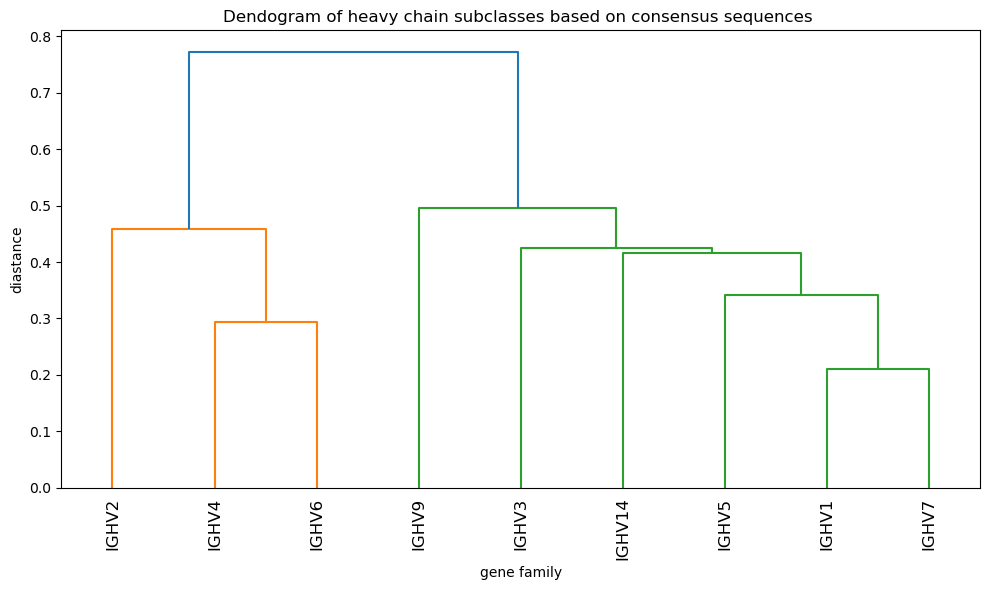

In [5]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, to_tree
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
from io import StringIO

# 1. Distance Matrix einlesen
file_path = "msa_consensus_output/distance_matrix.txt"

with open(file_path, "r") as f:
    lines = f.readlines()

# Anzahl der Sequenzen
n = int(lines[0].strip())

# Labels und Matrix extrahieren
labels = []
matrix = []

for line in lines[1:]:
    parts = line.strip().split()
    label = parts[0]
    values = list(map(float, parts[1:]))
    labels.append(label)
    matrix.append(values)

# 2. In ein DataFrame umwandeln
df = pd.DataFrame(matrix, index=labels, columns=labels)

# 3. In ein condensed Distance Array umwandeln (für linkage)
condensed_dist = squareform(df.values)

# 4. Hierarchisches Clustering (z.B. UPGMA / average linkage)
Z = linkage(condensed_dist, method='ward')

# 5. Dendrogramm zeichnen
plt.figure(figsize=(10, 6))
dendrogram(Z, labels=labels, leaf_rotation=90)
plt.title("Dendogram of heavy chain subclasses based on consensus sequences ")
plt.xlabel("gene family")
plt.ylabel("diastance")
plt.tight_layout()
plt.savefig("msa_consensus_output/consensus_tree.png")
plt.show()

creation of a heatmap as another approach to visualize the genfamily distances.

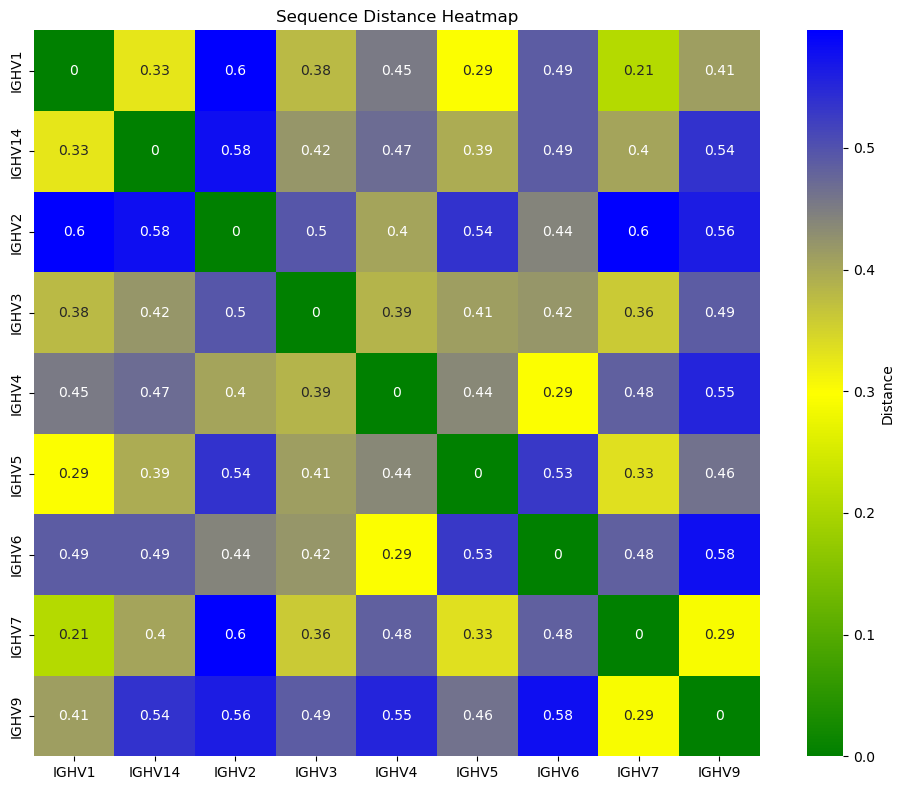

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Pfad relativ zu deinem Arbeitsordner (blasting)
file_path = "msa_consensus_output/distance_matrix.txt"

# Datei einlesen
with open(file_path, "r") as f:
    lines = f.readlines()

# Erste Zeile ist Anzahl der Items (kann ignoriert werden)
n = int(lines[0].strip())

# Die nächsten Zeilen in eine Liste von Listen splitten
data = []
row_labels = []
for line in lines[1:]:
    parts = line.strip().split()
    row_labels.append(parts[0])
    row_values = list(map(float, parts[1:]))
    data.append(row_values)

# DataFrame erstellen
df_matrix = pd.DataFrame(data, index=row_labels, columns=row_labels)

# Farbskala definieren: Rot (low) -> Gelb (mid) -> Grün (high)
colors = ["green", "yellow", "blue"]
cmap = LinearSegmentedColormap.from_list("red_yellow_green", colors)

plt.figure(figsize=(10, 8))
sns.heatmap(df_matrix, annot=True, cmap=cmap, square=True, cbar_kws={"label": "Distance"})
plt.title("Sequence Distance Heatmap")
plt.tight_layout()
plt.show()